In [54]:
# Data processing 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Feature enggineering 
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay

In [42]:
data = pd.read_csv("loan_approval_data.csv")

In [43]:
# Remove unnecessary column
data = data.drop(columns =["Applicant_ID","Marital_Status","Gender"])

# Add new feature: square of DTI_Ratio and Credit_Score
data["DTI_Ratio_sq"] = data["DTI_Ratio"] ** 2
data["Credit_Score_sq"] = data["Credit_Score"] ** 2

data = data.drop(columns =["DTI_Ratio","Credit_Score"])


# EDA

In [ ]:
# How classes are balanced
classes_count = data["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["NO","Yes"], autopct="%1.1f%%")
plt.title("Approved Loan percentage")

In [ ]:
sns.histplot(
    data = data,
    x = "Applicant_Income",
    bins = 20
)

In [ ]:
sns.histplot(
    data = data,
    x = "Coapplicant_Income",
    bins=20
)

In [ ]:
# outliers - box plots

sns.boxplot(
    data=data,
    x="Loan_Approved",
    y="Applicant_Income"
)

In [ ]:
fig, axes = plt.subplots(2, 3)

sns.boxplot(ax=axes[0, 0], data=data, x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0, 1], data=data, x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[0, 2], data=data, x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1, 0], data=data, x="Loan_Approved",y="Savings")
sns.boxplot(ax=axes[1, 1], data=data, x="Loan_Approved",y="Age")
sns.boxplot(ax=axes[1, 2], data=data, x="Loan_Approved",y="Loan_Amount")
plt.tight_layout()

In [ ]:
# Credit Score with Loan Approved

sns.histplot(
    data=data,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [ ]:
sns.histplot(
    data=data,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [ ]:
nums_cols = data.select_dtypes(include = "number")
corr_matrix = nums_cols.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

# Feature Engginerring 

In [44]:
# handling missing values
data = data.dropna(subset=["Loan_Approved"])

# Encode target variable

le = LabelEncoder()
data["Loan_Approved"] = le.fit_transform(data["Loan_Approved"])
y = data["Loan_Approved"]
X = data.drop(columns = ["Loan_Approved"])

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
# catgeorzing features into numerical and ordinal and nominal features

numerical_cols = data.select_dtypes(include =["float64"]).columns
ordinal_cols = ["Education_Level", "Property_Area",]
nominal_cols = ["Employment_Status", "Employer_Category", "Loan_Purpose"]


In [46]:
# pipelines for numerical and ordinal and nominal features

# Numerical pipeline
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="mean")),
    ('scaler', StandardScaler())
])

# Ordinal pipeline
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OrdinalEncoder(categories=[
    ['Not Graduate', 'Graduate'],  # Education_Level order
    ['Rural', 'Semiurban', 'Urban']  # Property_Area order
    ]))
])

# Nominal pipeline
nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OneHotEncoder(drop="first", handle_unknown="ignore"))
])

In [47]:
# colunmn transformer to apply pipelines to respective columns

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('ord', ordinal_pipeline, ordinal_cols),
    ('nom', nominal_pipeline, nominal_cols)
])

# Full pipeline = preprocessor + model
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000,solver='lbfgs',random_state=42))
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(eval_metric='logloss', random_state = 42))
])

In [48]:
# Define base models
estimators = [
    ('lr',lr_pipeline),
    ('rf', rf_pipeline),
    ('xgb', xgb_pipeline)
]

# Stacking Classifier
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    passthrough=False
)

In [49]:
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)
stacking_model.fit(X_train, y_train)

# Evaluation loop
models = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': rf_pipeline,
    'XGBoost': xgb_pipeline,
    'Stacking': stacking_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]  # for ROC-AUC
    
    print(f"\n{name}")
    print("Accuracy:  ", accuracy_score(y_test, y_pred))
    print("Precision: ", precision_score(y_test, y_pred))
    print("Recall:    ", recall_score(y_test, y_pred))
    print("F1 Score:  ", f1_score(y_test, y_pred))
    print("ROC-AUC:   ", roc_auc_score(y_test, y_prob))



Logistic Regression
Accuracy:   0.9
Precision:  0.875
Recall:     0.8032786885245902
F1 Score:   0.8376068376068376
ROC-AUC:    0.9650527385944847

Random Forest
Accuracy:   0.9578947368421052
Precision:  0.9076923076923077
Recall:     0.9672131147540983
F1 Score:   0.9365079365079365
ROC-AUC:    0.9788410217308425

XGBoost
Accuracy:   0.9578947368421052
Precision:  0.9076923076923077
Recall:     0.9672131147540983
F1 Score:   0.9365079365079365
ROC-AUC:    0.9902147668064557

Stacking
Accuracy:   0.9578947368421052
Precision:  0.9076923076923077
Recall:     0.9672131147540983
F1 Score:   0.9365079365079365
ROC-AUC:    0.9865294192400559


In [ ]:
kfold = KFold(n_splits=5, shuffle=True ,random_state=42)

models_cv = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': rf_pipeline,
    'XGBoost': xgb_pipeline,
    'Stacking': stacking_model
}

for name, model in models_cv.items():
    scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring="roc_auc")
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression: 0.9228 (+/- 0.0273)
Random Forest: 0.9812 (+/- 0.0111)
XGBoost: 0.9918 (+/- 0.0034)
Stacking: 0.9870 (+/- 0.0074)


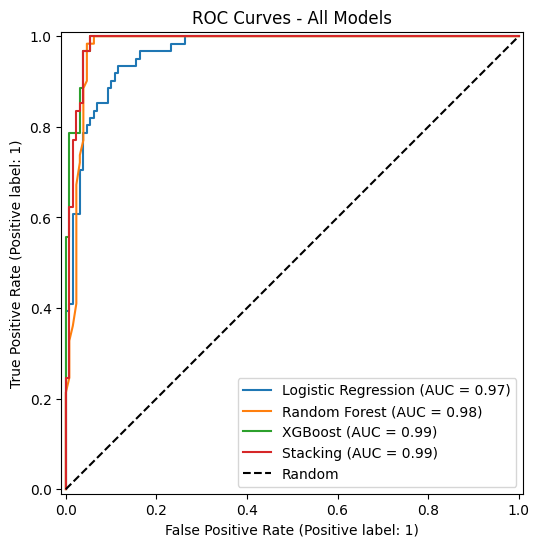

In [55]:
plt.figure(figsize=(10, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    RocCurveDisplay.from_predictions(
        y_test,      # true labels
        y_prob,      # predicted probabilities
        name=name, # model name
        ax=plt.gca()
    )

plt.title("ROC Curves - All Models")
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.legend()
plt.show()


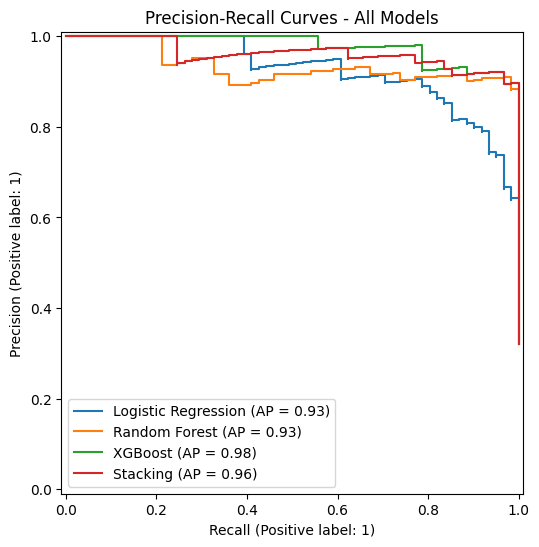

In [56]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(10, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_prob,
        name=name,
        ax=plt.gca()
    )

plt.title("Precision-Recall Curves - All Models")
plt.legend()
plt.show()